### trying to replicate the ViT paper (vision transformer)
link:https://arxiv.org/abs/2010.11929

In [1]:
import torch
import torchvision

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from pathlib import Path
image_path=Path("data/pizza_steak_sushi")
image_path

WindowsPath('data/pizza_steak_sushi')

In [4]:
train_dir=image_path/"train"
test_dir=image_path/"test"
train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [5]:
!nvidia-smi

Thu Jul 17 18:44:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   54C    P8              7W /   75W |     350MiB /   6144MiB |     26%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from going_modular import data_setup
from torchvision import transforms
IMG_SIZE=224

manual_transforms=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])

print(f"manually created transform: {manual_transforms}")

manually created transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
#making smallest version of the ViT
BATCH_SIZE=32

train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE,
)
len(train_dataloader),len(test_dataloader),class_names

(8, 3, ['pizza', 'steak', 'sushi'])

In [8]:
#visualize a single image
image_batch,label_batch=next(iter(train_dataloader))

image,label=image_batch[0],label_batch[0]

image.shape,label

(torch.Size([3, 224, 224]), tensor(0))

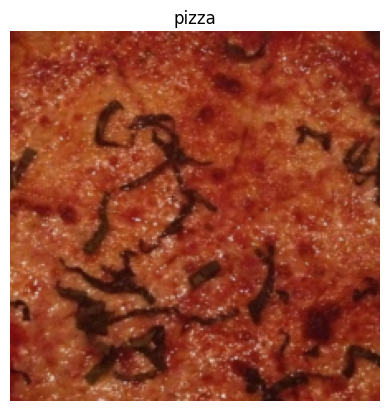

In [9]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1,2,0))#because matplot requires(h,w,c)
plt.title(class_names[label])
plt.axis(False);

In [10]:
#replicating the vit
#inputs:what goes into the model
#outputs:what comes out of the model/layer/blocks
#layers:takes an input,manipulates it with a function(eg.self-attention)
#block:stacks of the layers

#### The flowchart of the model

![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-figure-1-architecture-overview.png?raw=true)

#### Four equation

![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-four-equations.png?raw=true)

An overview of the model is depicted in Figure 1. The standard Transformer receives as input a 1D sequence of token embeddings. To handle 2D images, we reshape the image $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$ into a sequence of flattened 2D patches $\mathbf{x}_p \in \mathbb{R}^{N \times\left(P^2 \cdot C\right)}$, where $(H, W)$ is the resolution of the original image, $C$ is the number of channels, $(P, P)$ is the resolution of each image patch, and $N=H W / P^2$ is the resulting number of patches, which also serves as the effective input sequence length for the Transformer. The Transformer uses constant latent vector size $D$ through all of its layers, so we flatten the patches and map to $D$ dimensions with a trainable linear projection (Eq. 1). We refer to the output of this projection as the patch embeddings.

Similar to BERT's [class] token, we prepend a learnable embedding to the sequence of embedded patches $\left(\mathbf{z}_0^0=\mathbf{x}_{\text {class }}\right)$, whose state at the output of the Transformer encoder $\left(\mathbf{z}_L^0\right)$ serves as the image representation $\mathbf{y}$ (Eq. 4). Both during pre-training and fine-tuning, a classification head is attached to $\mathbf{z}_L^0$. The classification head is implemented by a MLP with one hidden layer at pre-training time and by a single linear layer at fine-tuning time.

Position embeddings are added to the patch embeddings to retain positional information. We use standard learnable 1D position embeddings, since we have not observed significant performance gains from using more advanced 2D-aware position embeddings (Appendix D.4). The resulting sequence of embedding vectors serves as input to the encoder.
The Transformer encoder (Vaswani et al., 2017) consists of alternating layers of multiheaded selfattention (MSA, see Appendix A) and MLP blocks (Eq. 2, 3). Layernorm (LN) is applied before every block, and residual connections after every block (Wang et al., 2019; Baevski \& Auli, 2019).

pseudo_code:
```python
#eq1
x_input=[class_token,image_patch_1,image_patch_2,.....,image_patch_N]+
        [class_token_pos,image_patch_1_pos,image_path_2_pos,......image_patch_N_pos]


#eq2
x_output_msa_block=msa_layer(ln_layer(x_input))+x_input

#eq3
x_output_mlp_block=mlp_layer(ln_layer(x_output_msa_block))+x_output_msa_block

#eq4
y = linear_layer(ln_layer(x_output_mlp_block))
```
#### Table
![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-table-1.png?raw=true)

* vit-base,vit-large and vit-huge are all different sizes of the same model architecture.
* layers:no of transformer encoder layers.
* hidden size $D$ - the embedding the size throuhgout the architecture.(eg-768 flatten layer dimmension)
* mlp size- the number of hidden units / neurons in the mlp
* head- the number of multi-head self-attention.

In [11]:
#equation 1
#trying to find the input and output shape of the eq1
#taking some sample example
height=224
width=224
color_channels=3
patch_size=16

#using the formula from the equation 1's explanation

no_of_patches=int((height*width)/patch_size**2)
no_of_patches

196

In [12]:
#input shape
embedding_layer_input_shape=(height,width,color_channels)
#output shape
embedding_layer_output_shape=(no_of_patches,patch_size**2*color_channels)

print(f"input shape : {embedding_layer_input_shape}")
print(f"output shape : {embedding_layer_output_shape}")

input shape : (224, 224, 3)
output shape : (196, 768)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

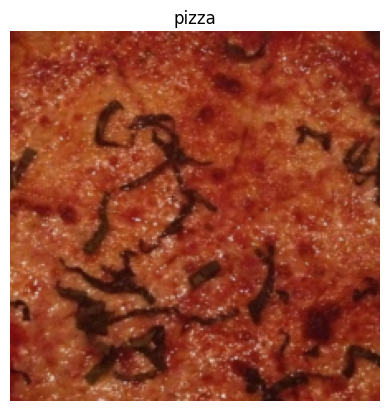

In [13]:
#now lets visualize how can we convert a image into patches
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [14]:
image.shape

torch.Size([3, 224, 224])

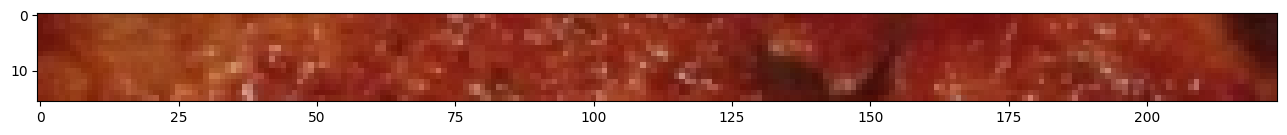

In [15]:
#lets get the top row
image_permuted=image.permute(1,2,0)

patch_size=16
plt.figure(figsize=(patch_size,patch_size))
plt.imshow(image_permuted[:patch_size,:,:])

the number of the patches in a row : 14.0


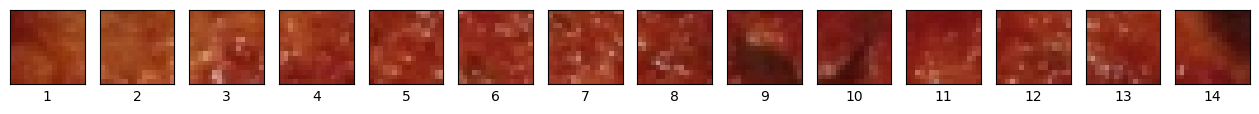

In [16]:
#lets try to plot the patches in the top row
img_size=224
patch_size=16
num_patches=img_size/patch_size
assert img_size%patch_size==0,"image size must be divisible by the patch size"
print(f"the number of the patches in a row : {num_patches}")

#creating the subplots
fig,axs=plt.subplots(nrows=1,
                     ncols=int(img_size//patch_size),
                     sharex=True,
                     sharey=True,
                     figsize=(patch_size,patch_size))

#now iterating through the images patches and ploting them
for i,patch in enumerate(range(0,img_size,patch_size)):
    axs[i].imshow(image_permuted[:patch_size,patch:patch+patch_size,:])
    axs[i].set_xlabel(i+1)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

total number of the patches :196.0


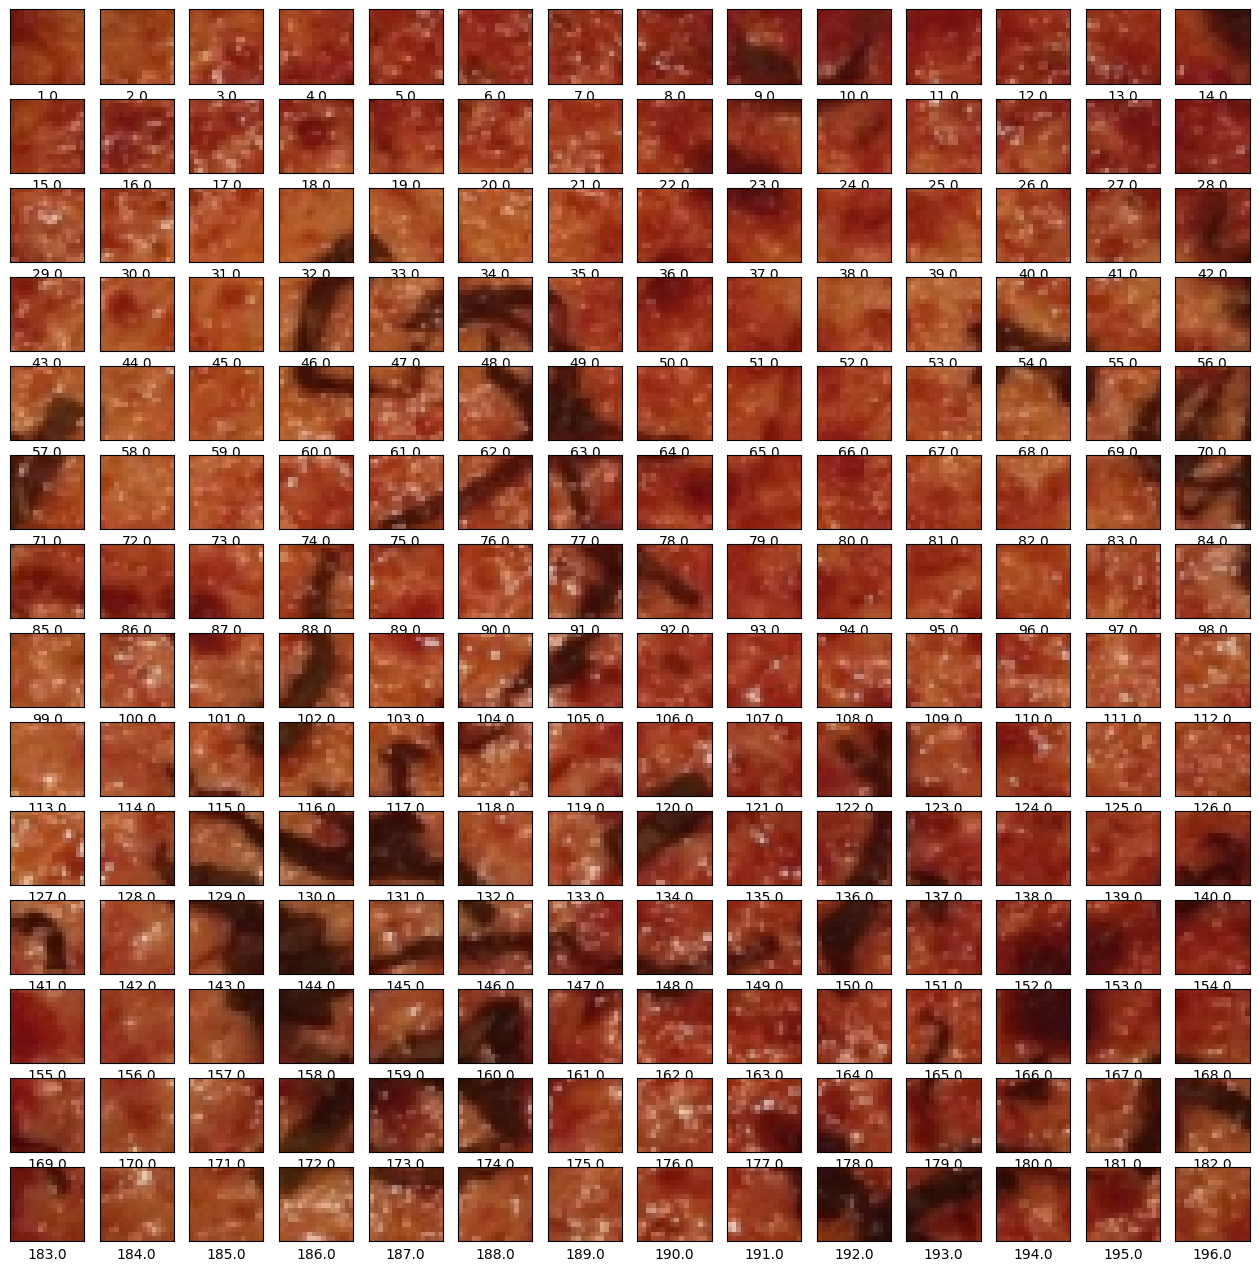

In [17]:
#lets try to create the whole image now
img_size=224
patch_size=16
num_patches=img_size/patch_size
assert img_size%patch_size==0,"image size must be divisible by the patch size"

print(f"total number of the patches :{num_patches**2}")

#creating the subplots
fig,axs=plt.subplots(nrows=img_size//patch_size,
                     ncols=img_size//patch_size,
                     sharex=True,
                     sharey=True,
                     figsize=(patch_size,patch_size))

#now iterating through the images patches and ploting them
for i,patch in enumerate(range(0,img_size,patch_size)):
    for j,patch2 in enumerate(range(0,img_size,patch_size)):
        axs[i,j].imshow(image_permuted[patch:patch+patch_size,patch2:patch2+patch_size,:])
        axs[i,j].set_xlabel(i*num_patches+j+1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])

In [18]:
#as this method of making patch takes time we can use conv2d layer for patching the image as well as embedding.
from torch import nn
patch_size=16
conv2d=nn.Conv2d(in_channels=3,#color channels
                 out_channels=768,#from table 1 count of D vit base
                 kernel_size=patch_size,
                 stride=patch_size,
                 padding=0)
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

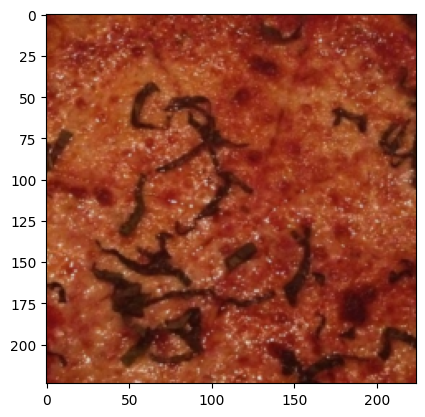

In [19]:
plt.imshow(image.permute(1,2,0))

In [20]:
#passing the image throuhg the layer
image_out_of_conv=conv2d(image.unsqueeze(0))#just adding up a dimension,because the covn2d layer expects images in batches
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


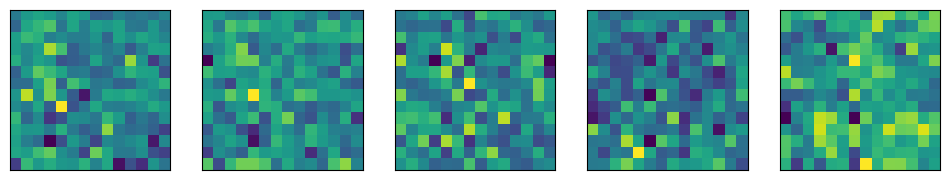

In [21]:
#now lets get some random convolutional feature maps embedding
import random
random_indexes=random.sample(range(0,768),k=5)

fig,axs=plt.subplots(nrows=1,ncols=5,figsize=(12,12))

for i,idx in enumerate(random_indexes):
    image_conv_feature_map=image_out_of_conv[:,idx,:,:]
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[],yticklabels=[],xticks=[],yticks=[])

In [22]:
#getting a single feature map in tensor form
single_feature_map=image_out_of_conv[:,0,:,:]
single_feature_map,single_feature_map.requires_grad

(tensor([[[0.1395, 0.1348, 0.1145, 0.1138, 0.1323, 0.1156, 0.1509, 0.1192,
           0.0700, 0.0734, 0.0745, 0.1150, 0.1584, 0.0664],
          [0.1672, 0.1319, 0.1488, 0.1698, 0.1596, 0.0885, 0.1508, 0.1435,
           0.0402, 0.0946, 0.1642, 0.2057, 0.0591, 0.0888],
          [0.1666, 0.1574, 0.1663, 0.2114, 0.1492, 0.2028, 0.1697, 0.1238,
           0.0744, 0.1163, 0.1730, 0.1350, 0.1257, 0.0927],
          [0.1240, 0.2673, 0.1855, 0.1159, 0.1847, 0.1810, 0.1605, 0.0905,
           0.1278, 0.1423, 0.2569, 0.1994, 0.2119, 0.1323],
          [0.1454, 0.2357, 0.1732, 0.1895, 0.1958, 0.1784, 0.0849, 0.1691,
           0.1165, 0.1099, 0.1998, 0.1530, 0.2001, 0.0505],
          [0.0885, 0.2140, 0.1754, 0.1409, 0.2026, 0.2372, 0.1009, 0.0916,
           0.1719, 0.1054, 0.1567, 0.1889, 0.1485, 0.1028],
          [0.1231, 0.1007, 0.1574, 0.1296, 0.1412, 0.1866, 0.0918, 0.1333,
           0.1345, 0.1233, 0.1864, 0.1698, 0.1817, 0.2096],
          [0.1873, 0.2186, 0.1464, 0.0402, 0.1621, 0.21

In [23]:
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


In [24]:
from torch import nn
flatten_layer=nn.Flatten(start_dim=2,
                         end_dim=3)
flatten_layer(image_out_of_conv).shape

torch.Size([1, 768, 196])

original image shape:torch.Size([3, 224, 224])
image feature map (patches) shape :torch.Size([1, 768, 14, 14])
flattened image feature map shape :torch.Size([1, 768, 196])


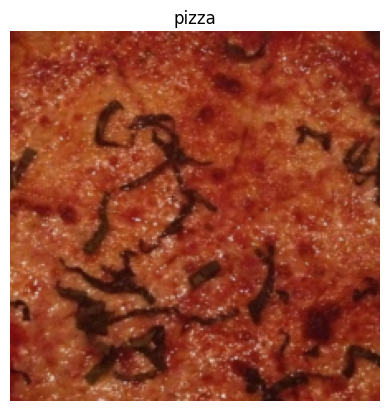

In [25]:
#lets put everything together
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)
print(f"original image shape:{image.shape}")

#turning image into patches then embedding (feature maps)
image_out_of_conv=conv2d(image.unsqueeze(0))
print(f"image feature map (patches) shape :{image_out_of_conv.shape}")

#flattening the feature map
image_out_of_conv_flattened=flatten_layer(image_out_of_conv)
print(f"flattened image feature map shape :{image_out_of_conv_flattened.shape}")

In [26]:
#rearrange the output of the feature map
image_out_of_conv_flattened_permuted=image_out_of_conv_flattened.permute(0,2,1)
image_out_of_conv_flattened_permuted.shape

torch.Size([1, 196, 768])

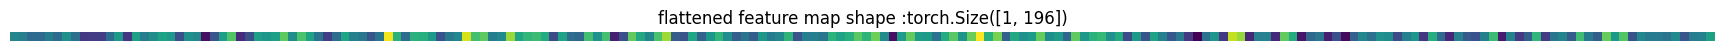

In [28]:
#lets get a single flattened feature map and visualise it
single_flattened_feature_map=image_out_of_conv_flattened_permuted[:,:,0]

plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"flattened feature map shape :{single_flattened_feature_map.shape}")
plt.axis(False);

In [29]:
#now we will make this whole modular that is taking it all into a class called patchembedding
class PatchEmbedding(nn.Module):
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()
        #creating a conv2d layer to turn an image into embedded patches
        self.patcher=nn.Conv2d(
            in_channels=in_channels,
            out_channels=embedding_dim,
            kernel_size=patch_size,
            stride=patch_size,
            padding=0)
        #creating a layer to form a flatten feature map from conv2d output
        self.flatten=nn.Flatten(start_dim=2,
                                end_dim=3)
    #making a forward pass to put all the layers and process together
    def forward(self,x):
        #checking if the input is correct
        image_resolution=x.shape[-1]
        assert image_resolution%patch_size==0,f"input image size must be divisible by the patch size"

        #using the layers
        x_patched=self.patcher(x)
        x_flattened=self.flatten(x_patched)
        #the embedding dimension must be in the correct order(batch_size,no_of_patches,embedding_dimension)
        return x_flattened.permute(0,2,1)

In [31]:
from helper_functions import set_seeds

In [ ]:
set_seeds()
patchify=PatchEmbedding(
    in_channels=3,
    patch_size=16,
    embedding_dim=768)

print(f"shape of the input image :{image.unsqueeze(0).shape}")#addding extra dimension for conv2d layer
patch_embedded_image=patchify(image.unsqueeze(0))
print(f"shape of the output patch embedding sequence :{patch_embedded_image.shape}")

shape of the input image :torch.Size([1, 3, 224, 224])
shape of the output patch embedding sequence :torch.Size([1, 196, 768])


In [33]:
#this patch embedding is the first layer of the vit base